# NeuroSegment-BraTS: Treinamento do Modelo (Deep Learning)

**Notebook 4.3:** Modelagem e Experimentação — SegResNet

Nesta etapa, instanciamos a arquitetura **SegResNet**, definimos os parâmetros de otimização e executamos o ciclo de treinamento.

**Metodologia Experimental:**
*   **Modelo:** SegResNet (CNN com residual blocks e encoder-decoder simétrico). Mais leve e eficiente que U-Net 3D, ideal como baseline rápido.
*   **Função de Perda:** `DiceCELoss`. Combinação de *Cross-Entropy* (classificação geral) com *Dice Loss* (desbalanceamento de classes).
*   **Otimizador:** Adam.
*   **Gestão de Hardware:** Treinamento em patches 96x96x96 com validação via `SlidingWindowInferer`.

## 1. Importações e Inicialização

In [1]:
import os
import torch
from monai.networks.nets import SegResNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import matplotlib.pyplot as plt

# Definindo o dispositivo de aceleração (CUDA/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinamento rodando no dispositivo: {device}")

# Limpeza preventiva do Cache da GPU
if device.type == 'cuda':
    torch.cuda.empty_cache()

# Post-processing para validação: converte logits e labels para one-hot
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Treinamento rodando no dispositivo: cuda


## 2. Ingestão do Pipeline de Dados
Abaixo, conectamos este notebook aos iteradores criados no Notebook 3.

In [2]:
import sys
sys.path.append('../')
from src.data_pipeline import get_dataloaders

# 1. Ingestão do Pipeline
train_loader, val_loader = get_dataloaders()
print("DataLoaders carregados com sucesso no Notebook 4.3!")

# Validando a conexão
test_batch = next(iter(train_loader))
print(f"Shape de entrada da imagem: {test_batch['image'].shape}")

Total de pacientes carregados na tubulação: 368
DataLoaders carregados com sucesso no Notebook 4.3!


/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape de entrada da imagem: torch.Size([4, 4, 96, 96, 96])


## 3. Definição da Arquitetura (SegResNet) e Hiperparâmetros
Configuramos o SegResNet para aceitar 4 canais de entrada (FLAIR, T1, T1ce, T2) e devolver predições para as nossas 4 classes de interesse.

**Diferenciais do SegResNet:**
- Arquitetura encoder-decoder com **residual blocks** (inspirado no ResNet), o que facilita o fluxo de gradientes e acelera a convergência.
- Mais leve que U-Net 3D e Swin UNETR, ideal como baseline rápido.
- `init_filters=16` para manter o modelo compacto e caber confortavelmente na GPU.

In [3]:
# 1. O Modelo: SegResNet
model = SegResNet(
    in_channels=4,              # 4 Modalidades (FLAIR, T1, T1ce, T2)
    out_channels=4,             # 4 Classes de saída (Background, NCR, ED, ET)
    init_filters=16,            # Filtros iniciais (compacto para 12GB VRAM)
    dropout_prob=0.2,           # Dropout para regularização
).to(device)

# 2. A Função de Perda (Loss Function)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# 3. O Otimizador
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

# 4. A Métrica de Avaliação Oficial (Dice Score)
dice_metric = DiceMetric(include_background=False, reduction="mean")

print(f"Modelo SegResNet instanciado com {sum(p.numel() for p in model.parameters()):,} parâmetros")

Modelo SegResNet instanciado com 4,702,244 parâmetros


## 4. O Ciclo de Treinamento e Validação
Executamos o treinamento iterativo. A cada *batch*, o modelo tenta segmentar o tumor, calcula o erro e ajusta seus pesos. Ao final de cada época, rodamos uma etapa de validação (sem aprender) para medir a performance real.

In [4]:
# Configurações do Loop
max_epochs = 10 # LEMBRAR DE MUDAR PARA A RODADA REAL <------------------------
val_interval = 2  # Roda validação a cada 4 épocas

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

print("INICIANDO O TREINAMENTO (SegResNet)...")

for epoch in range(max_epochs):
    print(f"\n--- Época {epoch + 1}/{max_epochs} ---")
    
    # === MODO DE TREINO ===
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        if step % 10 == 0:
            print(f"Lote {step}/{len(train_loader)} | Loss do Lote: {loss.item():.4f}")
            
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"--> Loss Médio da Época {epoch + 1}: {epoch_loss:.4f}")
    
    # === MODO DE VALIDAÇÃO ===
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["label"].to(device)
                
                # Sliding Window: processa o cérebro inteiro em pedaços de 96x96x96
                val_outputs = sliding_window_inference(
                    inputs=val_inputs, 
                    roi_size=(96, 96, 96), 
                    sw_batch_size=4, 
                    predictor=model
                )
                
                # Post-processing correto: argmax + one-hot para predições e labels
                val_outputs = [post_pred(i) for i in val_outputs]
                val_labels = [post_label(i) for i in val_labels]
                
                dice_metric(y_pred=val_outputs, y=val_labels)
            
            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric)
            
            print(f">>> Métrica Dice de Validação: {metric:.4f}")
            
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join("../models", "best_metric_model_segresnet.pth"))
                print("Novo recorde! Modelo salvo no disco.")

print(f"\nTREINAMENTO CONCLUÍDO! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}")

INICIANDO O TREINAMENTO (SegResNet)...

--- Época 1/10 ---
Lote 10/328 | Loss do Lote: 2.0595
Lote 20/328 | Loss do Lote: 1.8809
Lote 30/328 | Loss do Lote: 1.8027
Lote 40/328 | Loss do Lote: 1.6583
Lote 50/328 | Loss do Lote: 1.6804
Lote 60/328 | Loss do Lote: 1.6953
Lote 70/328 | Loss do Lote: 1.7076
Lote 80/328 | Loss do Lote: 1.6360
Lote 90/328 | Loss do Lote: 1.7031
Lote 100/328 | Loss do Lote: 1.5896
Lote 110/328 | Loss do Lote: 1.7065
Lote 120/328 | Loss do Lote: 1.6797
Lote 130/328 | Loss do Lote: 1.5947
Lote 140/328 | Loss do Lote: 1.6623
Lote 150/328 | Loss do Lote: 1.6602
Lote 160/328 | Loss do Lote: 1.5716
Lote 170/328 | Loss do Lote: 1.5410
Lote 180/328 | Loss do Lote: 1.4926
Lote 190/328 | Loss do Lote: 1.4728
Lote 200/328 | Loss do Lote: 1.4800
Lote 210/328 | Loss do Lote: 1.5764
Lote 220/328 | Loss do Lote: 1.5864
Lote 230/328 | Loss do Lote: 1.4489
Lote 240/328 | Loss do Lote: 1.4681
Lote 250/328 | Loss do Lote: 1.4483
Lote 260/328 | Loss do Lote: 1.4097
Lote 270/328 |

/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/

>>> Métrica Dice de Validação: 0.4872
Novo recorde! Modelo salvo no disco.

--- Época 3/10 ---
Lote 10/328 | Loss do Lote: 1.1630
Lote 20/328 | Loss do Lote: 1.1570
Lote 30/328 | Loss do Lote: 1.0417
Lote 40/328 | Loss do Lote: 1.0752
Lote 50/328 | Loss do Lote: 1.2195
Lote 60/328 | Loss do Lote: 1.2125
Lote 70/328 | Loss do Lote: 1.1460
Lote 80/328 | Loss do Lote: 1.1703
Lote 90/328 | Loss do Lote: 1.0330
Lote 100/328 | Loss do Lote: 1.1263
Lote 110/328 | Loss do Lote: 1.1172
Lote 120/328 | Loss do Lote: 0.9387
Lote 130/328 | Loss do Lote: 1.0506
Lote 140/328 | Loss do Lote: 1.0705
Lote 150/328 | Loss do Lote: 0.9911
Lote 160/328 | Loss do Lote: 1.0628
Lote 170/328 | Loss do Lote: 1.0828
Lote 180/328 | Loss do Lote: 1.0540
Lote 190/328 | Loss do Lote: 0.9725
Lote 200/328 | Loss do Lote: 1.1107
Lote 210/328 | Loss do Lote: 1.2084
Lote 220/328 | Loss do Lote: 1.0521
Lote 230/328 | Loss do Lote: 1.1677
Lote 240/328 | Loss do Lote: 1.0517
Lote 250/328 | Loss do Lote: 0.9617
Lote 260/328 |

## 5. Curvas de Aprendizado
Visualização da evolução do loss de treino e do Dice de validação ao longo das épocas.

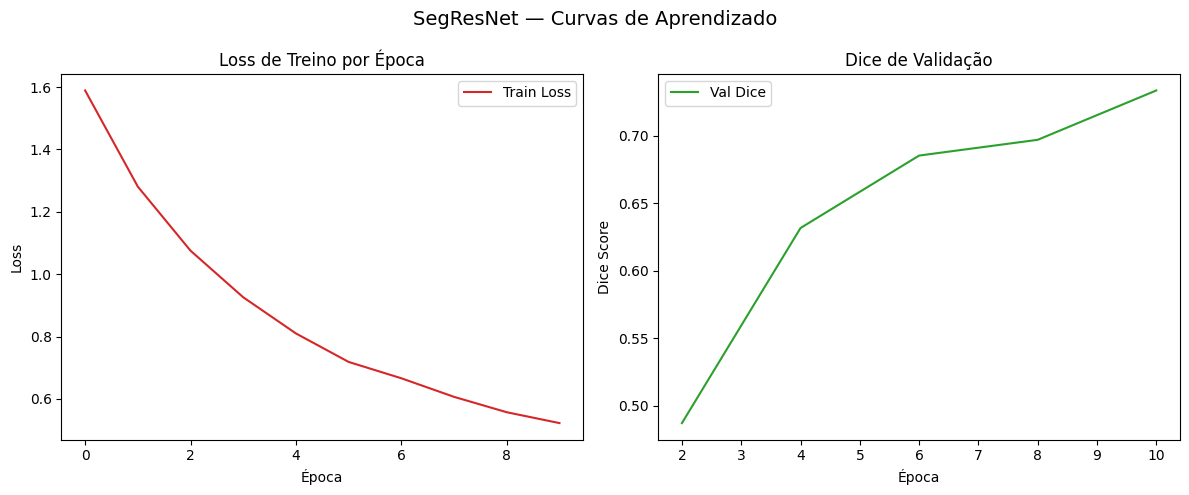

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Curva de Loss de Treino
ax1.plot(epoch_loss_values, label='Train Loss', color='tab:red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss de Treino por Época')
ax1.legend()

# Curva de Dice de Validação
val_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
ax2.plot(val_epochs, metric_values, label='Val Dice', color='tab:green')
ax2.set_xlabel('Época')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice de Validação')
ax2.legend()

plt.suptitle('SegResNet — Curvas de Aprendizado', fontsize=14)
plt.tight_layout()
plt.savefig('../models/segresnet_learning_curves.png', dpi=150)
plt.show()